# TUTORIAL: LIMPIEZA DE DATOS CON PYTHON Y PANDAS

Recordemos que se mantiene el ETL, extracción, transformación y cargar(load) los datos.




# 1. El problema del negocio

Una entidad bancaria contrata a una empresa de marketing encargada de contactar telefónicamente a posibles clientes para determinar si están interesados o no en adquirir un certificado de depósito a término (CDT) con el banco.

¿Qué perfil tienen los clientes con mayor potencial de conversión?

Es importantisimo conocer el contexto de los datos debido a que gracias a esto es que nos permitirá trabajar bien con las bases de datos.

En este caso queremos identificar los individuos orientados a que si pueden hacer este CDT. 

#2. El set de datos

La información recolectada por la empresa de mercadeo se encuentra en un archivo CSV (`dataset_banco.csv`) con 45215 filas y 17 columnas.

Cada registro contiene 16 características (las primeras 16 columnas) y una categoría ("yes" o "no" dependiendo de si la persona está o no interesada en adquirir el producto). Las columnas son:

1. "age":  edad (numérica)
2. "job": tipo de trabajo (categórica: "admin.", "unknown", "unemployed", "management", "housemaid", "entrepreneur", "student", "blue-collar","self-employed", "retired", "technician", "services")
3. "marital": estado civil (categórica: "married", "divorced", "single")
4. "education": nivel educativo (categórica: "unknown", "secondary", "primary", "tertiary")
5. "default": si dejó de pagar sus obligaciones (categórica: "yes", "no")
6. "balance": saldo promedio anual en euros (numérica)
7. "housing": ¿tiene o no crédito hipotecario? (categórica: "yes", "no")
8. "loan": ¿tiene créditos de consumo? (categórica: "yes", "no")
9. "contact": medio a través del cual fue contactado (categórica: "unknown", "telephone", "cellular")
10. "day": último día del mes en el que fue contactada (numérica)
11. "month": último mes en el que fue contactada (categórica: "jan", "feb", "mar", ..., "nov", "dec")
12. "duration": duración (en segundos) del último contacto (numérica)
13. "campaign": número total de veces que fue contactada durante la campaña (numérica)
14. "pdays": número de días transcurridos después de haber sido contactado antes de la campaña actual (numérica. -1 indica que no fue contactado previamente)
15. "previous": número de veces que ha sido contactada antes de esta campaña (numérica)
16. "poutcome": resultado de la campaña de marketing anterior (categórica: "unknown", "other", "failure", "success")
17. "y": categoría ¿el cliente se suscribió a un depósito a término? (categórica: "yes", "no")

#3. Una primera mirada al dataset

In [1]:
import sys
print(sys.executable) #para ver donde esta el ejecutable con el interprete de python 

c:\Users\mtang\AppData\Local\Programs\Python\Python313\python.exe


In [2]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt #librería usada para graficar
import seaborn as sns #Librería usada para visualización
import os


In [3]:
os.getcwd() #para ver el directorio de trabajo actual

'c:\\Users\\mtang\\OneDrive\\Escritorio\\Documentos_Estudio\\Estadistica\\IMD\\Clases\\Parte_1_preprocesamiento'

# Lectura de la base de datos:

En la primera opción debemos subir la base de datos al directorio por defecto de colab.

En la segunda opción, podemos conectarnos al archivo almacenado en google drive.

In [4]:
ruta = "../../datos/dataset_banco.csv"
data = pd.read_csv(ruta)#lectura con pandas

Primero que nada, luego de cargar las librerías y cargar todos los datos damos un vistazo al datset. 

In [5]:
print(data.shape) #45189 filas por 17 variables
data.head()

(45215, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no


In [6]:
# Veamos las variables categóricas y las numéricas
data.info() #ver todos los tipos de variables.

#Es una buena práctica cambiar el tipo de dato para controlar 
#el espacio de memoria que usa cada una de las variables. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45215 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45215 non-null  int64  
 1   job        45213 non-null  object 
 2   marital    45214 non-null  object 
 3   education  45214 non-null  object 
 4   default    45215 non-null  object 
 5   balance    45213 non-null  float64
 6   housing    45215 non-null  object 
 7   loan       45215 non-null  object 
 8   contact    45215 non-null  object 
 9   day        45215 non-null  int64  
 10  month      45215 non-null  object 
 11  duration   45214 non-null  float64
 12  campaign   45215 non-null  int64  
 13  pdays      45214 non-null  float64
 14  previous   45215 non-null  int64  
 15  poutcome   45215 non-null  object 
 16  y          45215 non-null  object 
dtypes: float64(3), int64(4), object(10)
memory usage: 5.9+ MB


Por tanto, es importantisimo entender que los primeros casos son:
- 1. Entender el contexto del problema.
- 2. Entender las variables con las que se están trabajando.
- 3. Mirar la base de datos para entenderla.

# 4. Limpieza
Luego de analizar de como esta compuesta la base de datos realizaremos el proceso de limpieza teniendo en cuenta las situaciones más comunes:

0. Revisar los nombres de las variables y organizar los tipos de datos siempre que se pueda, pues muchas veces 
esto permite facilidad en el trabajo con los mismos además de que puede volver todo más optimo. 
1. Datos faltantes en algunas celdas
2. Columnas irrelevantes (que no responden al problema que queremos resolver)
3. Registros (filas) repetidos
4. Valores extremos (*outliers*) en el caso de las variables numéricas. Se deben analizar en detalle pues no necesariamente la solución es eliminarlos
5. Errores tipográficos en el caso de las variables categóricas

Al final de este proceso de limpieza deberíamos tener un set de datos **íntegro**, listo para la fase de Análisis Exploratorio.

# Nombres de las variables
Como directamente los nombres de las variables son claros, entonces se opta por no cambiarlos. 

Es importante hacer un análisis de variable por variable y sus elementos para ver si hay que organizar los datos, pues por ejemplo para el caso categórico puede ser el mismo valor escrito de una manera incorrecta y eso sería una categoría más sin necesidad. Para las variables numéricas pues puede tener directamente datos atípicos o cosas inexplicables.

## 4.1 Datos faltantes

Acá comenzamos a ver que los datos no están completos, pues no todas las columnas tienen la misma cantidad de registros.

El número total de registros debería ser 45.215. Sin embargo columnas como "job", "marital", "education", "balance", "duration" y "pdays".

**Por ser tan pocos los datos  faltantes optaremos por eliminar las filas correspondientes**:

In [7]:
data.dropna(inplace=True) #quitar todos los Na's. inplace=True es para que se guarde
#en la memoria donde se tiene este data frame.
#Ese dropna quita toda la fila donde haya un dato vacío. 
#en caso de que se quisiera quitar la columna se pone axis=1. 

data.info() #información de la base de datos.

<class 'pandas.core.frame.DataFrame'>
Index: 45207 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45207 non-null  int64  
 1   job        45207 non-null  object 
 2   marital    45207 non-null  object 
 3   education  45207 non-null  object 
 4   default    45207 non-null  object 
 5   balance    45207 non-null  float64
 6   housing    45207 non-null  object 
 7   loan       45207 non-null  object 
 8   contact    45207 non-null  object 
 9   day        45207 non-null  int64  
 10  month      45207 non-null  object 
 11  duration   45207 non-null  float64
 12  campaign   45207 non-null  int64  
 13  pdays      45207 non-null  float64
 14  previous   45207 non-null  int64  
 15  poutcome   45207 non-null  object 
 16  y          45207 non-null  object 
dtypes: float64(3), int64(4), object(10)
memory usage: 6.2+ MB


## 4.2 Columnas irrelevantes

Una columna irrelevante puede ser:

- **Una columna que no contiene información relevante para el problema que queremos resolver**. Por ejemplo en este caso podría ser una columna que no guarde relación con el posible perfil del cliente (deporte favorito, hobbies, comida favorita, etc.)
- **Una columna categórica pero con un sólo nivel**. Por ejemplo si en la columna "job" solo tuviésemos el nivel "unknown".
- **Una columna numérica pero con un sólo valor**. Por ejemplo si en la columna "edad" todos los vlaores fuesen iguales a 50.
- **Columnas con información redundante**. Por ejemplo si además de las columnas "month" y "day" tuviésemos la columna "month-day", resultado de combinar las dos anteriores.

Aunque la relevancia de una variable la da el contexto del problema y el conocimiento que se tenga del mismo, si tenemos la duda de si alguna columna puede ser relevante o no lo mejor es dejarla (y más adelante en posteriores etapas podremos darnos cuenta de si se debe preservar o no).


En este caso todas las columnas pueden resultar relevantes, pero debemos verificar que no haya columnas categóricas con un sólo nivel, o columnas numéricas con un sólo valor:

In [ ]:
data.columns #para obtener las columnas. 

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [11]:
# Supongamos que tienes un DataFrame df
# Obtener columnas categóricas (objeto o category)
data_categoricas = data.select_dtypes(include=['object', 'category'])

# Ver los nombres de las columnas categóricas
print(data_categoricas.columns)


Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


In [12]:
data_categoricas.dtypes

job          object
marital      object
education    object
default      object
housing      object
loan         object
contact      object
month        object
poutcome     object
y            object
dtype: object

In [20]:
data["y"].unique() #para ver los valores únicos de la variable y.
data["y"].nunique() #para ver el número de valores únicos de la variable y.



2

In [ ]:
type(data.columns) # pandas.core.indexes.Index es un objeto de tipo Index,
#que es una estructura de datos utilizada por pandas para representar los nombres de las columnas en un DataFrame.

print(data.columns)
data.columns.shape
#funciona de una manera similar a una lista,
#pero tiene algunas características adicionales que
# lo hacen más eficiente para ciertas operaciones.

data.columns[0:5] #para ver las primeras 5 columnas

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


Index(['age', 'job', 'marital', 'education', 'default'], dtype='object')

In [39]:
for i, col in enumerate(data_categoricas.columns):
    print(f"Columna {i}: {data_categoricas[col]}")
    print(data_categoricas[col].value_counts())
    print("\n")

# Recordemos que el value_counts sirve de manera similar al count() de R
# pues hace un conteo por cada valor de la variable. 

Columna 0: 0          management
1          technician
2        entrepreneur
3         blue-collar
4             unknown
             ...     
45210      technician
45211         retired
45212         retired
45213     blue-collar
45214    entrepreneur
Name: job, Length: 45207, dtype: object
job
blue-collar       9730
management        9454
technician        7597
admin.            5166
services          4153
retired           2263
self-employed     1578
entrepreneur      1487
unemployed        1303
housemaid         1240
student            938
unknown            288
administrative       3
Management           2
MANAGEMENT           2
Self-employed        1
Services             1
Retired              1
Name: count, dtype: int64


Columna 1: 0         married
1          single
2         married
3         married
4          single
           ...   
45210     married
45211    divorced
45212     married
45213     married
45214     married
Name: marital, Length: 45207, dtype: object
marital


In [40]:
# Conteo de los niveles en las diferentes columnas categóricas
cols_cat = ['job', 'marital', 'education', 'default', 'housing',
       'loan', 'contact', 'month', 'poutcome', 'y']

for col in cols_cat:
  print(f'Columna {col}: {data[col].nunique()} subniveles')
#nunique() sirve para mostrar los valores únicos de cada variable.
#pues si una variable categórica tiene un solo valor pues entonces no será tan 
#útil para los análisis. 

Columna job: 18 subniveles
Columna marital: 6 subniveles
Columna education: 10 subniveles
Columna default: 2 subniveles
Columna housing: 2 subniveles
Columna loan: 6 subniveles
Columna contact: 5 subniveles
Columna month: 12 subniveles
Columna poutcome: 6 subniveles
Columna y: 2 subniveles


Todas las columnas categóricas tienen más de 1 subnivel. No eliminaremos ninguna.

Verifiquemos lo que ocurre con las columnas numéricas:

In [41]:
data.describe() #solo aplica a variables numéricas.

,age,balance,day,duration,campaign,pdays,previous
count,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000
mean,41.005596,1374.201318,15.806534,258.032539,2.763731,40.178225,0.580198
std,12.037399,3924.491665,8.323015,257.460759,3.098058,100.103283,2.303341
min,18.000000,-8019.000000,1.000000,-1389.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1427.500000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,776.000000,527532.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Todas las columnas numéricas tienen desviaciones estándar ("std") diferentes de cero, lo que indica que no tienen un único valor. Sin embargo, es notable que hay algunas inconsistencias en los datos por lo que más adelante hay que corregirlas. 

Preservaremos todas las columnas numéricas.

## 4.3 Filas repetidas

In [42]:
print(f'Tamaño del set antes de eliminar las filas repetidas: {data.shape}')
data.drop_duplicates(inplace=True)
print(f'Tamaño del set después de eliminar las filas repetidas: {data.shape}')

#Este método funciona si dos filas tiene TODOS sus datos idénticos. 

Tamaño del set antes de eliminar las filas repetidas: (45207, 17)
Tamaño del set después de eliminar las filas repetidas: (45203, 17)


El método de drop_duplicates es un métod que sirve para eliminar duplicados pero depende si se esta trabajando con estruturas de datos como listas o como pandas.

## Con pandas:
df_sin_duplicados = df.drop_duplicates()

subset: Permite especificar una columna o lista de columnas para identificar los duplicados (por defecto usa todas).

keep: Define qué ocurrencia mantener.
'first' (por defecto): Mantiene la primera aparición.

'last': Mantiene la última aparición.

False: Elimina todas las filas que tengan duplicados.

inplace=True: Modifica el DataFrame original directamente en lugar de devolver uno nuevo.

ignore_index=True: Reindexa las filas de 0 a n-1 tras la eliminación

también puede eliminarse solo por medio de una columna con:

df.drop_duplicates(subset=['nombre_variable'])

de esta manera es que se eliminan los duplicados según la varible indicada.

Es o(n) en promedio (análisis amortizado) gracias a que pandas usa tablas de hash altamente optimizadas en C

In [36]:

df = pd.DataFrame({'A': [1, 1, 2], 'B': ['x', 'x', 'y']})

# Eliminar duplicados manteniendo el primero
df_limpio = df.drop_duplicates(subset=['A'], keep='last')
df_limpio


,A,B
1,1,x
2,2,y


## 4.4 *Outliers* en las variables numéricas

No siempre se deben eliminar los *outliers* porque dependiendo de la variable numérica analizada estos pueden contener información importante.

Creemos gráficas tipo "boxplot" de las columnas numéricas:

In [43]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 45203 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45203 non-null  int64  
 1   job        45203 non-null  object 
 2   marital    45203 non-null  object 
 3   education  45203 non-null  object 
 4   default    45203 non-null  object 
 5   balance    45203 non-null  float64
 6   housing    45203 non-null  object 
 7   loan       45203 non-null  object 
 8   contact    45203 non-null  object 
 9   day        45203 non-null  int64  
 10  month      45203 non-null  object 
 11  duration   45203 non-null  float64
 12  campaign   45203 non-null  int64  
 13  pdays      45203 non-null  float64
 14  previous   45203 non-null  int64  
 15  poutcome   45203 non-null  object 
 16  y          45203 non-null  object 
dtypes: float64(3), int64(4), object(10)
memory usage: 6.2+ MB
None


In [46]:
data.select_dtypes(include=["number"]).columns #seleccionar varibles numéricas

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

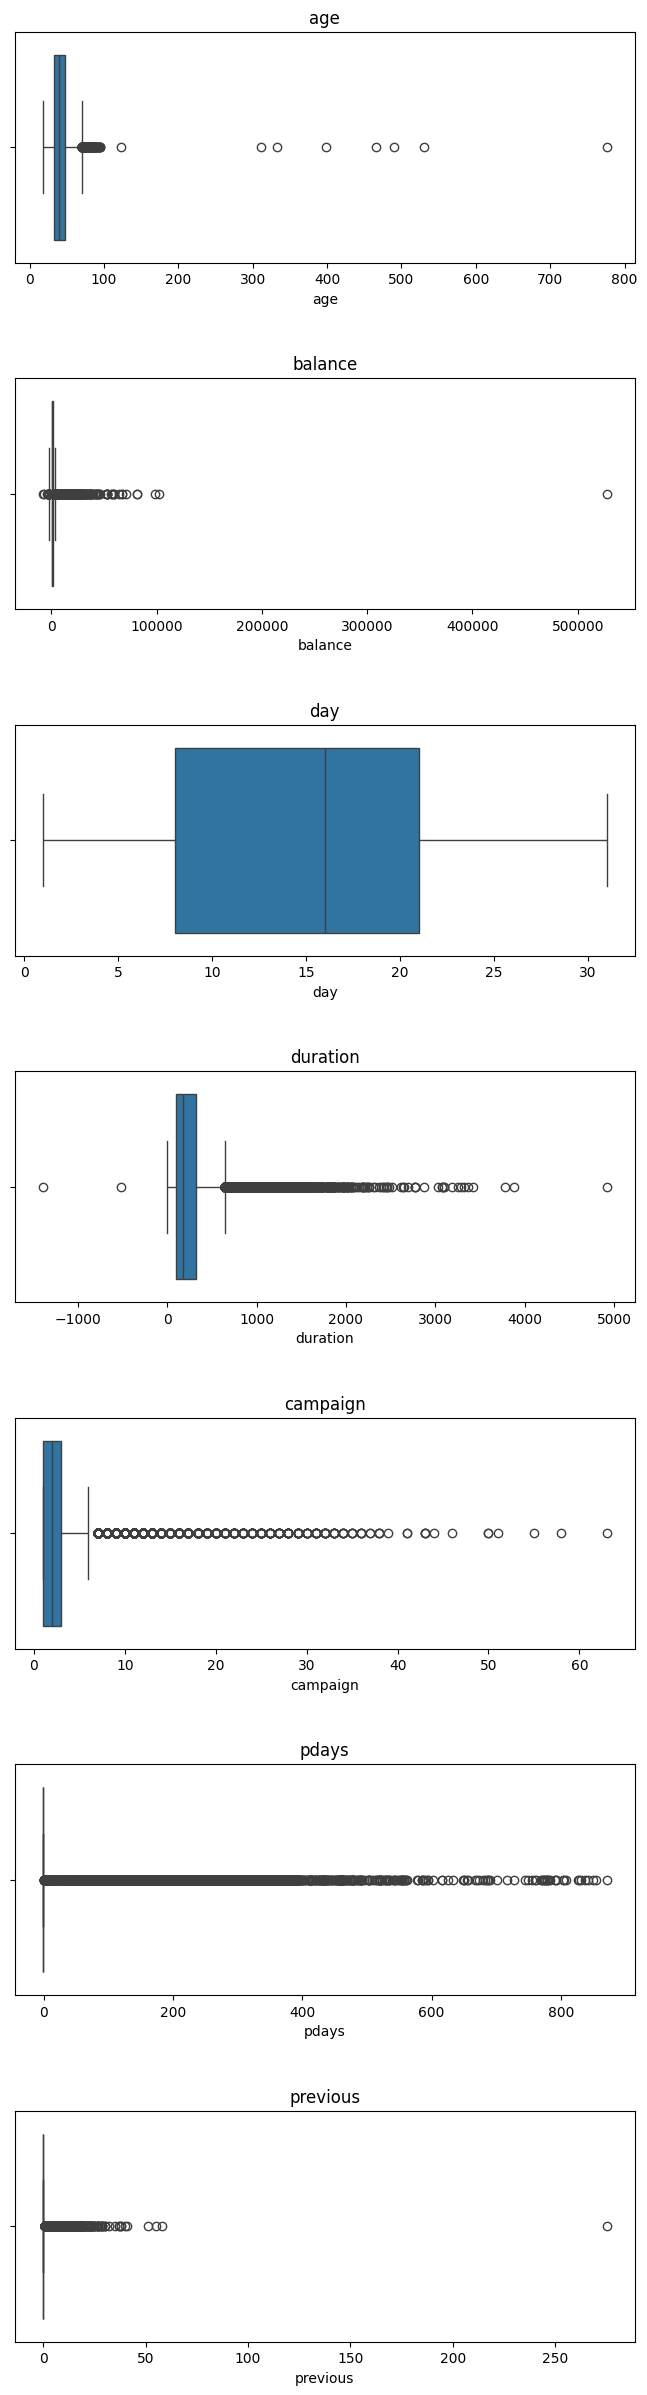

In [43]:
# Generar gráficas individuales pues las variables numéricas
# están en rangos diferentes

cols_num = ['age', 'balance', 'day', 'duration', 'campaign',
            'pdays', 'previous'] #variables numéricas


#crear un recuadro de 7 filas y una coluna, de 8x30 pulgadas
fig, ax = plt.subplots(nrows=7, ncols=1, figsize=(8,30))

#fig: es el objeto de la figura completa (contenedor global)

#ax: es un array que contiene los 7 objetos de ejes individuales.
#ax[0] es el primero, ax[1] el segundo y así. 

fig.subplots_adjust(hspace=0.5) #espacio ENTRE gráficos

for i, col in enumerate(cols_num):
    
    #x: le dice que columna gráficas
    #data=data : indica la fuente de los datos
    #ax[i] indica que debe dibujar en el recuadro i
    sns.boxplot(x=col, data=data, ax=ax[i])
    
    #agrega el título
    ax[i].set_title(col) 

**Observaciones:**
- "age": hay sujetos con edades mucho mayores a 100 años
- "duration": hay valores negativos
- "previous": hay un valor extremadamente alto (cercano a 300)

In [44]:
# Eliminar filas con "age">100
print(f'Tamaño del set antes de eliminar registros de edad: {data.shape}')
data = data[data['age']<=100]
print(f'Tamaño del set después de eliminar registros de edad: {data.shape}')

Tamaño del set antes de eliminar registros de edad: (45203, 17)
Tamaño del set después de eliminar registros de edad: (45195, 17)


In [45]:
# Eliminar filas con "duration"<0
print(f'Tamaño del set antes de eliminar registros de duración: {data.shape}')
data = data[data['duration']>0]
print(f'Tamaño del set después de eliminar registros de duración: {data.shape}')

Tamaño del set antes de eliminar registros de duración: (45195, 17)
Tamaño del set después de eliminar registros de duración: (45190, 17)


In [46]:
# Eliminar filas con "previous">100
print(f'Tamaño del set antes de eliminar registros de previous: {data.shape}')
data = data[data['previous']<=100]
print(f'Tamaño del set después de eliminar registros de previous: {data.shape}')

Tamaño del set antes de eliminar registros de previous: (45190, 17)
Tamaño del set después de eliminar registros de previous: (45189, 17)


## 4.5 Errores tipográficos en variables categóricas

En una variable categórica pueden aparecer sub-niveles como "unknown" y "UNK" que para nosotros son equivalentes pero que para nuestro programa parecerían diferentes.

Se deben unificar estos sub-niveles

C:\Users\mtang\AppData\Local\Temp\ipykernel_3336\971239731.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(),rotation=30) #nombre de categorías,
C:\Users\mtang\AppData\Local\Temp\ipykernel_3336\971239731.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(),rotation=30) #nombre de categorías,
C:\Users\mtang\AppData\Local\Temp\ipykernel_3336\971239731.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(),rotation=30) #nombre de categorías,
C:\Users\mtang\AppData\Local\Temp\ipykernel_3336\971239731.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks

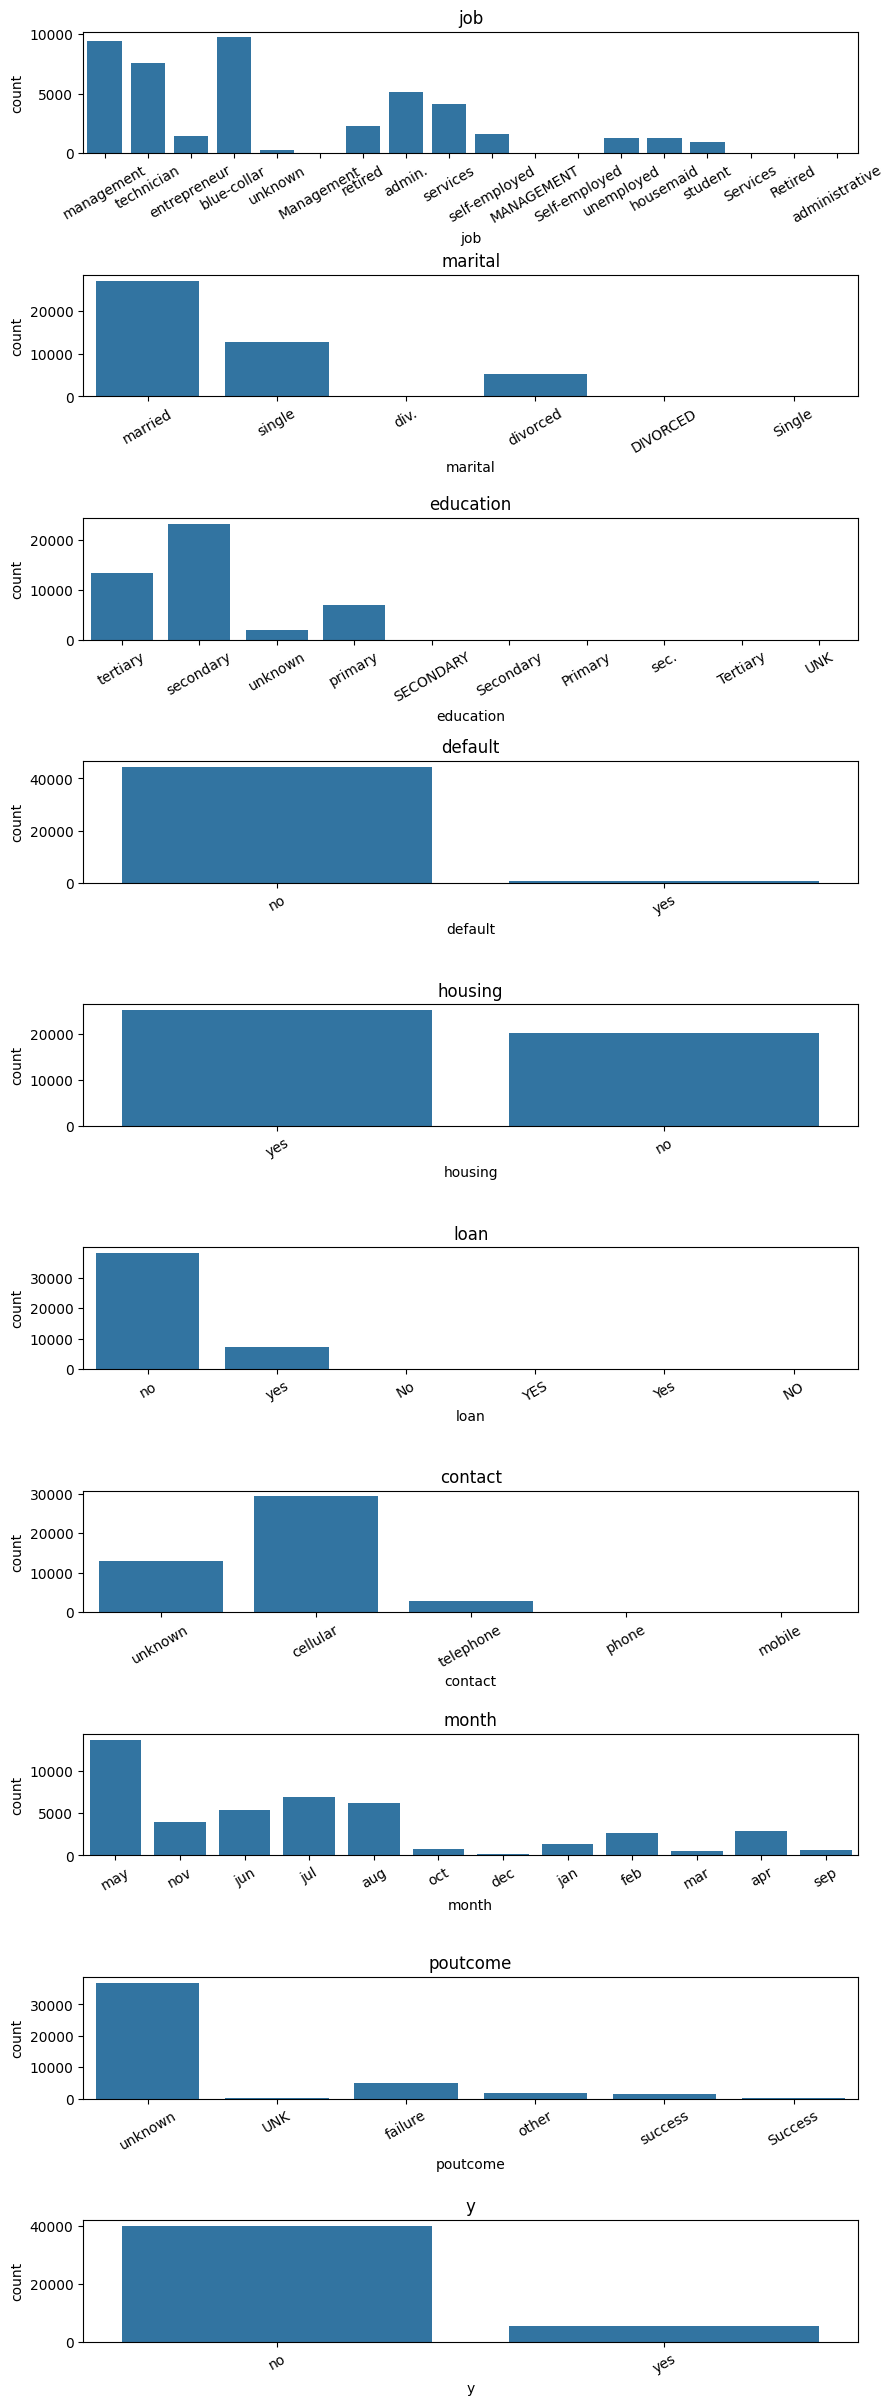

In [48]:
# Graficar los subniveles de cada variable categórica
cols_cat = ['job', 'marital', 'education', 'default', 'housing',
       'loan', 'contact', 'month', 'poutcome', 'y']

#crear figura de 10 filas y 1 columna, con cuadros de 10x30 pulgadas 
fig, ax = plt.subplots(nrows=10, ncols=1, figsize=(10,30))
fig.subplots_adjust(hspace=1) #1 unidad entre gráficas

for i, col in enumerate(cols_cat):
  
  #countplot para mostrar la cantidad de registros por categoría de variable
  sns.countplot(x=col, data=data, ax=ax[i]) # es solo para número de registros
  ax[i].set_title(col) # que el titulo sea el mismo que el nombre de la variable
  ax[i].set_xticklabels(ax[i].get_xticklabels(),rotation=30) #nombre de categorías,
  #girados 30 grados. 
  

Inicialmente se observa que hay sub-niveles con el mismo nombre pero escritos en minúscula, en mayúscula o con la primera letra en mayúscula.

Unifiquemos estos sub-niveles inicialmente:

C:\Users\mtang\AppData\Local\Temp\ipykernel_3336\1490683806.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(),rotation=30)
C:\Users\mtang\AppData\Local\Temp\ipykernel_3336\1490683806.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(),rotation=30)
C:\Users\mtang\AppData\Local\Temp\ipykernel_3336\1490683806.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(),rotation=30)
C:\Users\mtang\AppData\Local\Temp\ipykernel_3336\1490683806.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xti

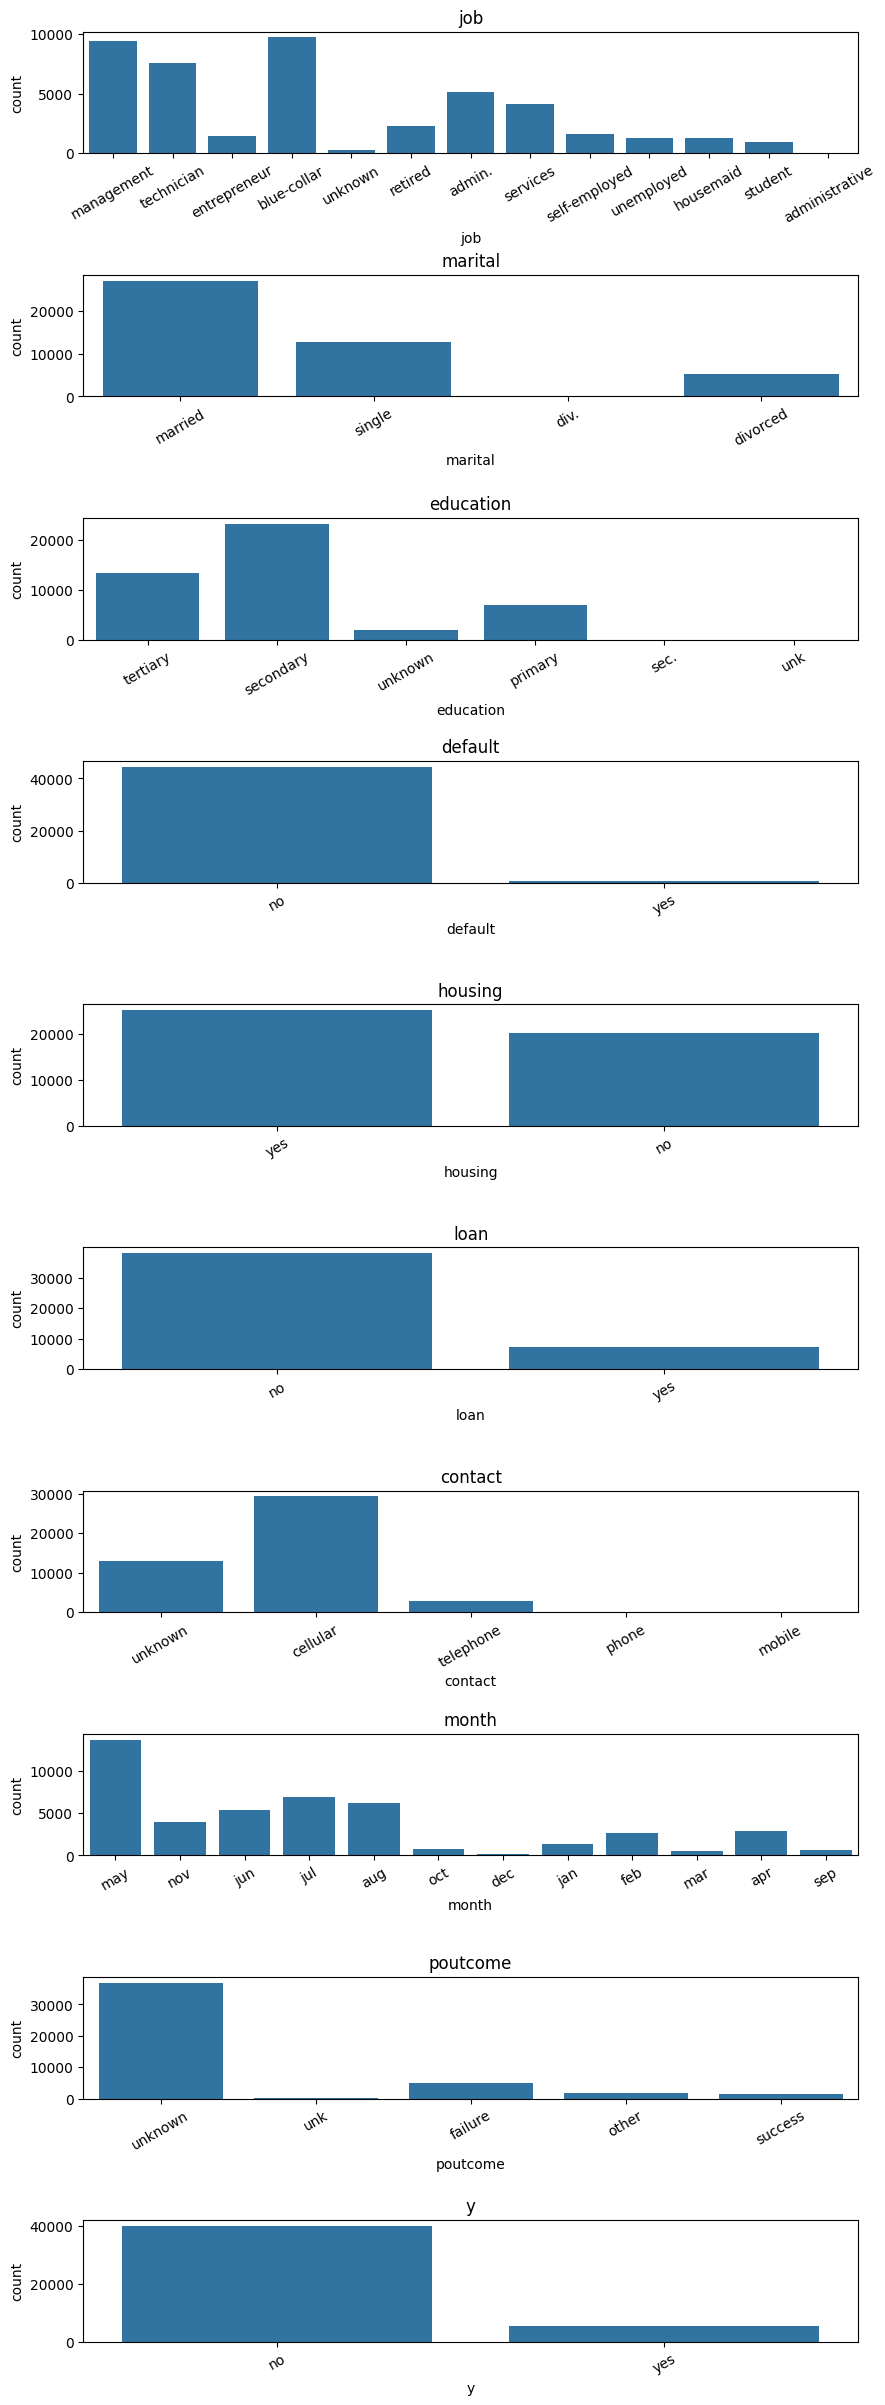

In [49]:
for column in data.columns:
    # Representar en minúsculas sólo si la columna es categórica
    if column in cols_cat:
        data[column] = data[column].str.lower() #volvemos todo en minúsculas

# Y generemos las gráficas nuevamente
fig, ax = plt.subplots(nrows=10, ncols=1, figsize=(10,30))
fig.subplots_adjust(hspace=1)

for i, col in enumerate(cols_cat):
  sns.countplot(x=col, data=data, ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xticklabels(ax[i].get_xticklabels(),rotation=30)

Corrección y normalización de categorías de variables categóricas. 

In [ ]:
# Variable job: unificar admin. y administrative

print(data['job'].unique()) #tomar los valores únicos de la variable

data['job'] = data['job'].str.replace('admin.','administrative', regex=False)

#todo lo que tenga admin se cambia por administrative
#regex=False le dice a python que tome la función como una cadena de texto literal
#y como como una expresión regular

print(data['job'].unique())

['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student' 'administrative']
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'administrative' 'services' 'self-employed' 'unemployed'
 'housemaid' 'student']


In [50]:
# marital: unificar div. y divorced
print(data['marital'].unique())
data['marital'] = data['marital'].str.replace('div.','divorced', regex=False)
print(data['marital'].unique())

['married' 'single' 'div.' 'divorced']
['married' 'single' 'divorced']


In [ ]:
# education: unificar sec. y secondary, unk y unknown
print(data['education'].unique())

data['education'] = data['education'].str.replace('sec.','secondary', regex=False)

#donde la variable education es igual a unk, se cambia por unknown
data.loc[data['education']=='unk','education'] = 'unknown'

print(data['education'].unique())

['tertiary' 'secondary' 'unknown' 'primary' 'sec.' 'unk']
['tertiary' 'secondary' 'unknown' 'primary']


In [52]:
# contact: unificar telephone y phone
print(data['contact'].unique())
data.loc[data['contact']=='phone','contact'] = 'telephone'
data.loc[data['contact']=='mobile','contact'] = 'cellular'
print(data['contact'].unique())

['unknown' 'cellular' 'telephone' 'phone' 'mobile']
['unknown' 'cellular' 'telephone']


In [53]:
# poutcome: unificar unk y unknown
print(data['poutcome'].unique())
data.loc[data['poutcome']=='unk','poutcome']='unknown'
print(data['poutcome'].unique())

['unknown' 'unk' 'failure' 'other' 'success']
['unknown' 'failure' 'other' 'success']


In [54]:
data.shape

(45189, 17)

¡Y listo, ya hemos realizado la limpieza de nuestro set de datos!

Originalmente tenía 45.215 registros y 17 columnas. El dataset resultante tiene 45.189 filas (26 menos) y 17 columnas.

El set de datos ya está listo para el Análisis Exploratorio.

In [ ]:
#ruta='/content/drive/MyDrive/Materias/Estadística/IMD/datos'
#data.to_csv(ruta, index=False) 
#para guardar los datos con formato csv

data.to_csv('../../datos/datos_banco_limpio.csv',index=False) #index=False para que no se añada una columna de índices

In [57]:
os.getcwd()

'c:\\Users\\mtang\\OneDrive\\Escritorio\\Documentos_Estudio\\Estadistica\\IMD'